In [37]:
import pandas as pd
import os
import shutil
import subprocess
from tqdm import tqdm
import json
from ast import literal_eval
import re
import requests
from Bio import pairwise2
import pickle
import sys
sys.path.append('../')
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

from common import *

# input and output

In [38]:
import json
with open('../../Result/ec_strain_enzymecounts_top4_filter_family.json', "r", encoding="utf-8") as f:
    enzyme_eccounts_dict = json.load(f)

print(len(enzyme_eccounts_dict))
# enzyme_eccounts_dict

4978


In [39]:
drugbank_result_file = '../../Result/drugbank_drug_deg_result_allec3.csv'
drugbank_result = pd.read_csv(drugbank_result_file)
drugbank_result["ec3_list"] = drugbank_result["ec3_list"].apply(
    lambda x: ast.literal_eval(x))
drugbank_result

,drug_name,reaction_num,ec3_num,ec3_list
0,Gramicidin D,132,17,"[6.3.2, 1.14.13, 1.14.15, 1.1.1, 1.2.7, 1.2.99..."
1,Desmopressin,100,33,"[6.3.4, 3.1.3, 3.4.13, 1.14.19, 3.8.1, 3.5.1, ..."
2,Cyclosporine,103,24,"[3.1.3, 3.4.13, 1.14.19, 3.5.1, 6.3.2, 1.14.13..."
3,Pyridoxal phosphate,38,35,"[1.6.5, 2.7.1, 3.1.3, 4.2.2, 3.8.1, 6.3.2, 1.1..."
4,Cyanocobalamin,129,30,"[3.1.3, 3.4.13, 1.14.19, 3.8.1, 3.5.1, 1.14.3,..."
...,...,...,...,...
1910,Vorasidenib,18,11,"[1.14.13, 1.11.2, 1.8.99, 3.2.1, 1.14.18, 1.14..."
1911,Pirtobrutinib,48,21,"[2.7.1, 4.2.2, 1.14.3, 3.8.1, 3.5.1, 1.14.13, ..."
1912,Lomifylline,59,27,"[2.7.1, 4.2.2, 1.14.19, 3.8.1, 1.14.15, 1.14.1..."
1913,Revumenib,59,15,"[1.14.13, 1.14.15, 2.1.1, 1.14.99, 3.2.1, 6.2...."


In [40]:
drugbank_result_ec_list = list(set([x for ec_list in drugbank_result['ec3_list']for x in ec_list]))
print(len(drugbank_result_ec_list))
print(len(enzyme_eccounts_dict))
enzyme_eccounts_dict = {k: v for k, v in enzyme_eccounts_dict.items() if '.'.join(k.split('.')[:3]) in drugbank_result_ec_list}
print(len(enzyme_eccounts_dict))

158
4978
4534


In [41]:
import numpy as np

def shannon_entropy(counts):
    counts = np.array(counts)
    total = counts.sum()
    
    if total == 0:
        return 0
    
    p = counts / total
    p = p[p > 0]
    
    H = -np.sum(p * np.log(p))
    H_norm = H / np.log(len(counts))  # 归一化
    
    return H_norm

In [42]:
ec_sensitivity = {}

for ec, family_dict in enzyme_eccounts_dict.items():
    counts = list(family_dict.values())
    ec_sensitivity[ec] = shannon_entropy(counts)
ec_sensitivity

{'2.7.1.202': 0.36669104544687214,
 '2.1.1.242': 0.17387370155249499,
 '3.2.2.22': 0.32798823036231417,
 '3.2.1.1': 0.3428446591019102,
 '1.1.5.2': 0.26698670493137006,
 '1.4.3.2': 0.4722434567448904,
 '3.4.24.7': 0.3746305056364868,
 '1.8.1.8': 0.3543612535162319,
 '2.3.1.269': 0.27597897084524287,
 '5.2.1.8': 0.38669441010570826,
 '3.4.11.5': 0.21294618329434167,
 '1.5.1.3': 0.49728795851498625,
 '2.1.1.45': 0.47303866663362915,
 '2.4.1.291': 0.18898391770963877,
 '2.7.7.40': 0.5195513116917374,
 '2.7.7.103': 0.5513072004214048,
 '2.1.1.17': 0.24498829178243017,
 '3.6.5.n1': 0.4900815475942271,
 '3.1.3.25': 0.4465297040523845,
 '2.4.2.10': 0.49591996449125625,
 '4.1.1.23': 0.5120764255968527,
 '6.3.4.2': 0.46346478471444874,
 '6.3.5.5': 0.5872294868984931,
 '2.1.3.2': 0.49335568921069284,
 '2.4.2.9': 0.5280007929023828,
 '1.8.1.4': 0.33044179725063944,
 '2.3.1.12': 0.46250421562149757,
 '3.4.16.4': 0.4088428129240389,
 '2.4.2.29': 0.4931435260825306,
 '1.8.1.16': 0.22150538656159258,

In [43]:
print(len(ec_sensitivity))
print(len({k:v for k,v in ec_sensitivity.items() if v<0.5}))

4534
3737


In [44]:
3737/4534

0.8242170269078076

# Shannon entropy

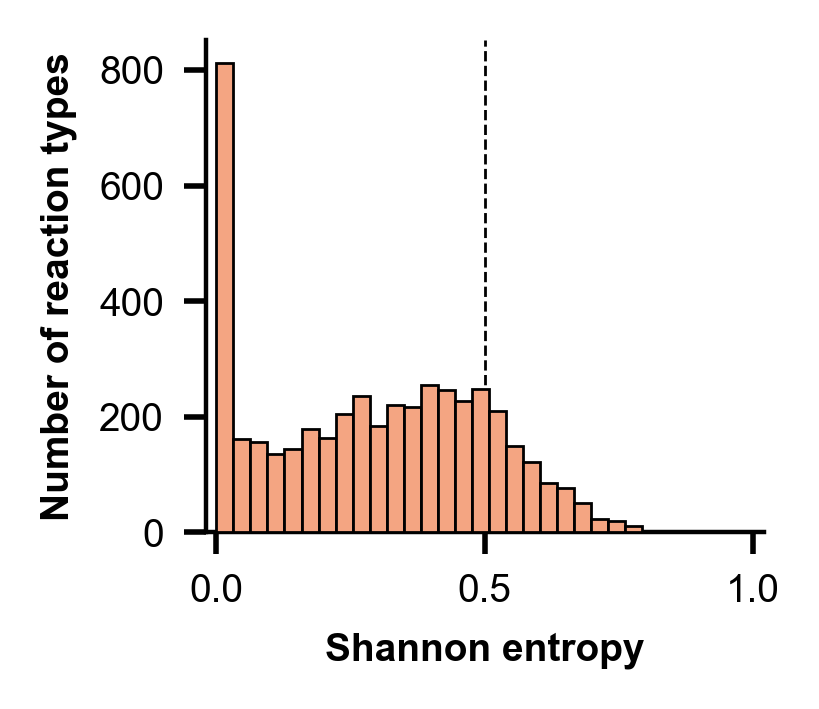

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# ===== 高亮 EC =====
highlight_ec_list = ['1.7.1.6','1.7.1.16','4.1.1.25','3.5.4.5',
                     '2.3.1.5','4.2.2.5','3.5.2.6','3.2.1.23',
                     '2.4.2.2','1.3.1.1','3.2.1.31','3.5.4.1',
                     '1.17.1.4']

# ===== 提取 x =====
x = []
ec_list = []

for ec, values in ec_sensitivity.items():
    ec_list.append(ec)
    x.append(values)

x = np.array(x)
ec_array = np.array(ec_list)

# ===== high-light mask =====
mask_highlight = np.isin(ec_array, highlight_ec_list)

# ===== figure =====
plt.figure(figsize=(1.8, 1.6), dpi=400)
plt.rcParams.update({'font.size': 7})
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['pdf.fonttype'] = 42

# ===== histogram（全体分布）=====
plt.hist(x, bins=25, color='#f4a582', alpha=1, edgecolor='black', linewidth=0.5, zorder = 3)

# ===== 高亮 EC overlay =====
# plt.hist(x[mask_highlight],
#          bins=30,
#          color='#f4a582',
#          alpha=0.9,
#          edgecolor='none')

# ===== 参考线（你原来的阈值）=====
plt.axvline(0.5, linestyle='--', linewidth=0.5, color='black')

# plt.text(0.505, plt.ylim()[1]*0.9,
#          'Cutoff = 0.5',
#          rotation=0,
#          fontsize=7,
#          va='top',
#          ha='left')
# ===== labels =====
plt.xlabel('Shannon entropy', fontsize=7, fontweight='bold')
plt.ylabel('Number of reaction types', fontsize=7, fontweight='bold')

plt.xticks(fontsize=7)
plt.yticks(fontsize=7)

plt.tick_params(axis='both', direction='out', width=1, length=4)
plt.xlim(-0.02,1.02)
# ===== 美化边框 =====
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.savefig('../../Figure/Figure-4f.pdf', dpi=400, bbox_inches='tight')
plt.show()

In [46]:
num=0
for k,v in data.items():
    if v[0]>0.5:
        num+=1
print(num,num/len(data))

NameError: name 'data' is not defined

In [ ]:
data

{'1.1.1.n12': [0.3708359884337954, 1197],
 '1.1.1.n11': [-0.0, 1197],
 '1.1.1.n4': [-0.0, 1197],
 '1.1.1.n5': [-0.0, 1197],
 '1.1.1.1': [0.30192650104036095, 1197],
 '1.1.1.2': [0.03612549973572894, 1197],
 '1.1.1.3': [0.4163807190742165, 1197],
 '1.1.1.4': [0.5746611376760821, 1197],
 '1.1.1.6': [0.341707481381222, 1197],
 '1.1.1.8': [0.6840614871931592, 1197],
 '1.1.1.9': [0.15055488748360613, 1197],
 '1.1.1.10': [0.5356865900213872, 1197],
 '1.1.1.11': [-0.0, 1197],
 '1.1.1.12': [-0.0, 1197],
 '1.1.1.14': [0.32368638907108904, 1197],
 '1.1.1.15': [0.06446631702527524, 1197],
 '1.1.1.16': [0.15174379346219674, 1197],
 '1.1.1.17': [0.4056617417325404, 1197],
 '1.1.1.18': [0.30621747949634964, 1197],
 '1.1.1.21': [0.14489361252101224, 1197],
 '1.1.1.22': [0.5076412819119813, 1197],
 '1.1.1.23': [0.32799009661589695, 1197],
 '1.1.1.24': [0.18783653092202046, 1197],
 '1.1.1.25': [0.44121045841853596, 1197],
 '1.1.1.27': [0.45768921265147633, 1197],
 '1.1.1.28': [0.41941395230226625, 1197